In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

x_img = cv2.imread("Lab0dados/lena.tif")

print(x_img.dtype)
print(x_img.shape)

uint8
(512, 512, 3)


In [23]:
cv2.imwrite("file1.jpg", x_img, (cv2.IMWRITE_JPEG_QUALITY, 80))
cv2.imwrite("file2.jpg", x_img, (cv2.IMWRITE_JPEG_QUALITY, 10))

True

In [24]:
Ia = plt.imread("file1.jpg")
Ib = plt.imread("file2.jpg")

MSE = np.mean((Ia - Ib) ** 2)

Ic = Ia * 1
Id = Ib * 1
MSE = np.mean((Ic - Id) ** 2)

Porg = np.mean(Ic ** 2)
Perr = np.mean((Ic - Id) ** 2)
SNR = 10 * np.log10(Porg / Perr)
print("SNR (dBs): ", SNR)

PSNR = 10 * np.log10(255 ** 2 / Perr)
print("PSNR (dBs): ", PSNR)

SNR (dBs):  3.211537646538954
PSNR (dBs):  31.06790165985945


In [25]:
x_img_g = cv2.cvtColor(x_img, cv2.COLOR_BGR2GRAY)
cv2.imwrite("file3.bmp", x_img_g)

print(x_img_g.shape)

(512, 512)


/var/folders/q8/0zrhfvpj419gsw2hfmxv_klw0000gn/T/ipykernel_26552/3077081453.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(x_img_g.ravel(), 256, [0, 256])


(262144,)
215


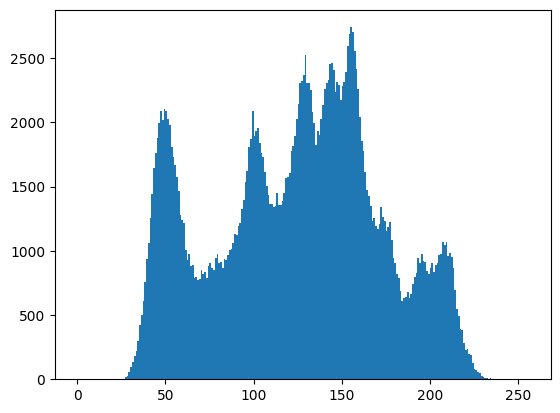

In [26]:
plt.hist(x_img_g.ravel(), 256, [0, 256])

print(x_img_g.ravel().shape)

Igray = plt.imread("file3.bmp")

ar = []
for i in x_img_g.ravel():
    if i in ar:
        continue
    else:
        ar.append(i)
print(len(ar))


Text(0.5, 1.0, 'bit8')

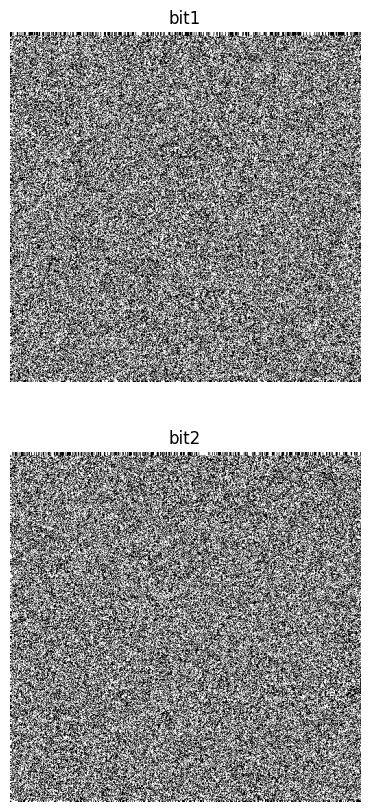

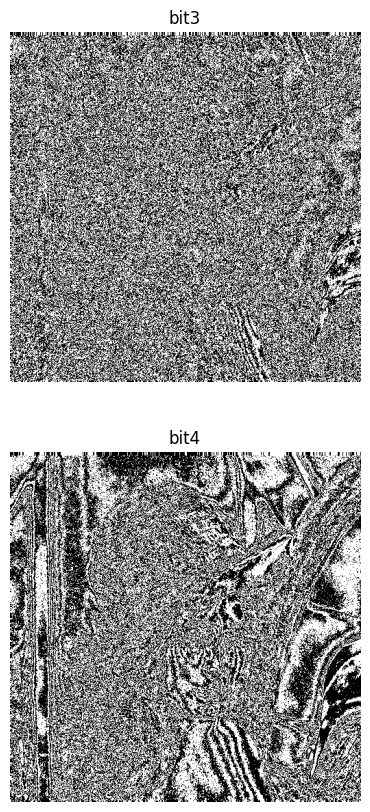

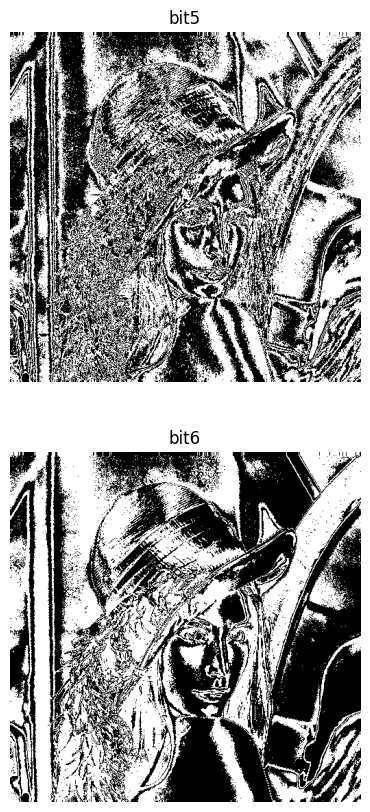

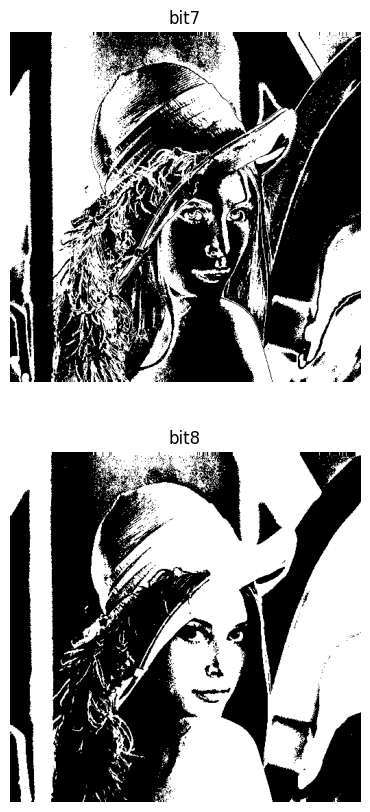

In [27]:
plt.figure(figsize=(20, 10))
plt.subplot(211)
I1 = (Igray%2)*255
plt.imshow(I1, cmap="gray")
plt.axis('off')
plt.title('bit1')
plt.subplot(212)
I2 = ((Igray>>1)%2)*255
plt.imshow(I2, cmap='gray')
plt.axis('off')
plt.title('bit2')
plt.figure(figsize=(20, 10))
plt.subplot(211)
I3 = ((Igray>>2)%2)*255
plt.imshow(I3, cmap='gray')
plt.axis('off')
plt.title('bit3')
plt.subplot(212)
I4 = ((Igray>>3)%2)*255
plt.imshow(I4, cmap='gray')
plt.axis('off')
plt.title('bit4')   
plt.figure(figsize=(20, 10))
plt.subplot(211)
I5 = ((Igray>>4)%2)*255
plt.imshow(I5, cmap='gray')
plt.axis('off')
plt.title('bit5')   
plt.subplot(212)
I6 = ((Igray>>5)%2)*255
plt.imshow(I6, cmap='gray')
plt.axis('off')
plt.title('bit6')
plt.figure(figsize=(20, 10))
plt.subplot(211)
I7 = ((Igray>>6)%2)*255
plt.imshow(I7, cmap='gray')
plt.axis('off')
plt.title('bit7')   
plt.subplot(212)
I8 = ((Igray>>7)%2)*255
plt.imshow(I8, cmap='gray')
plt.axis('off')
plt.title('bit8')


[[162 162 162 ... 170 155 128]
 [162 162 162 ... 170 155 128]
 [162 162 162 ... 170 155 128]
 ...
 [ 43  43  50 ... 104 100  98]
 [ 44  44  55 ... 104 105 108]
 [ 44  44  55 ... 104 105 108]]
[[255.   0. 255. ... 255. 255.   0.]
 [255. 255.   0. ... 255.   0. 255.]
 [  0. 255. 255. ... 255. 255.   0.]
 ...
 [  0.   0.   0. ...   0.   0. 255.]
 [  0.   0.   0. ... 255.   0.   0.]
 [  0. 255.   0. ... 255.   0. 255.]]


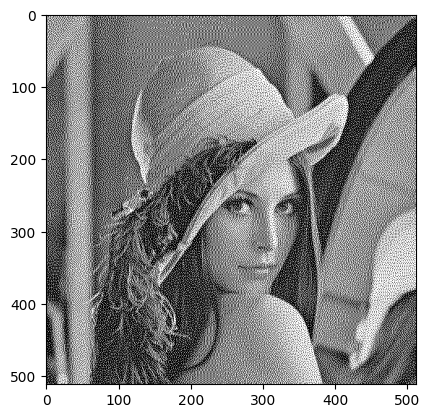

In [28]:
#Ex 6
"""
def dither(ar):
    for i in range(len(ar)):
        for j in range(len(ar[i])):
            #ultima linha e ultima coluna
            if i == len(ar) - 1 and  j == len(ar[i]) - 1:
                pass
            #ultima linha
            elif i == len(ar) - 1:
                ar[i, j + 1] = ar[i, j + 1] * (7/16)
            #primeira coluna
            elif j == 0:
                ar[i, j + 1] = ar[i, j + 1] * (7/16)
                ar[i + 1, j] = ar[i + 1, j] * (5/16)
                ar[i + 1, j + 1] = ar[i + 1, j + 1] * (1/16)
            #ultima coluna
            elif j == len(ar[i]) - 1:
                ar[i + 1, j - 1] = ar[i + 1, j - 1] * (3/16)
                ar[i + 1, j] = ar[i + 1, j] * (5/16)
            #geral
            else:
                ar[i, j + 1] = ar[i, j + 1] * (7/16)
                ar[i + 1, j - 1] = ar[i + 1, j - 1] * (3/16)
                ar[i + 1, j] = ar[i + 1, j] * (5/16)
                ar[i + 1, j + 1] = ar[i + 1, j + 1] * (1/16)
    print(ar)
    return ar
"""

def quant(v):
    if v >= 128:
        return 255
    else:
        return 0

def dither(ar):
    height = len(ar)
    width = len(ar[0])
    ar = ar.astype(float)
    for i in range(len(ar)):
        for j in range(len(ar[0])):
            op = ar[i][j]
            np = quant(op)
            ar[i][j] = np
            erro = op - np

            #ultima linha e ultima coluna
            if i == height - 1 and  j == width - 1:
                pass
            #ultima linha
            elif i == height - 1:
                ar[i][j + 1] += (erro * (7/16))
            #primeira coluna
            elif j == 0:
                ar[i][j + 1] += (erro * (7/16))
                ar[i + 1][j] += (erro * (5/16))
                ar[i + 1][j + 1] += (erro * (1/16))
            #ultima coluna
            elif j == width - 1:
                ar[i + 1][j - 1] += (erro *(3/16))
                ar[i + 1][j] += (erro * (5/16))
            #geral
            else:
                ar[i][j + 1] += (erro * (7/16))
                ar[i + 1][j - 1] += (erro *(3/16))
                ar[i + 1][j] += (erro * (5/16))
                ar[i + 1][j + 1] += (erro * (1/16))
    return ar
            
           
        

y = dither(x_img_g)
print(x_img_g)
print(y)

plt.imshow(y, cmap='gray')
plt.imsave("file4.bmp", y.astype(np.uint16), cmap='gray')

[[255   0 255 ... 255 255   0]
 [255 255   0 ... 255   0 255]
 [  0 255 255 ... 255 255   0]
 ...
 [  0   0   0 ...   0   0 255]
 [  0   0   0 ... 255   0   0]
 [  0 255   0 ... 255   0 255]]
SNR (dBs):  inf
PSNR (dBs):  inf


/var/folders/q8/0zrhfvpj419gsw2hfmxv_klw0000gn/T/ipykernel_26552/1329629180.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  SNR = 10 * np.log10(Porg / Perr)
/var/folders/q8/0zrhfvpj419gsw2hfmxv_klw0000gn/T/ipykernel_26552/1329629180.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  PSNR = 10 * np.log10(255 ** 2 / Perr)


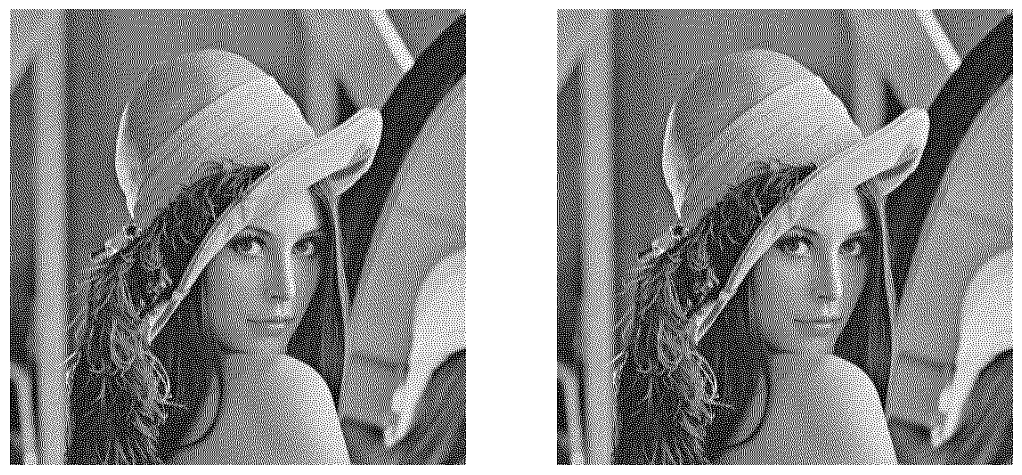

In [37]:
def binarizar_imagem(filepath):
    I = cv2.imread(filepath, 0)
    limFixo = I.mean()
    I1 = (255*(I>limFixo)).astype('uint8')
    plt.figure(figsize=(20, 10))
    plt.subplot(131)
    plt.imshow(I, cmap='gray')
    plt.axis('off')

    plt.subplot(132)
    plt.imshow(I1, cmap='gray')
    plt.axis('off')

    plt.imsave("file4binario.bmp", I1, cmap='gray')

    return I, I1

    
Ia, Ib = binarizar_imagem("file4.bmp")

print(Ib)

MSE = np.mean((Ia - Ib) ** 2)

Porg = np.mean(Ia ** 2)
Perr = np.mean((Ia - Ib) ** 2)
SNR = 10 * np.log10(Porg / Perr)
print("SNR (dBs): ", SNR)

PSNR = 10 * np.log10(255 ** 2 / Perr)
print("PSNR (dBs): ", PSNR)    

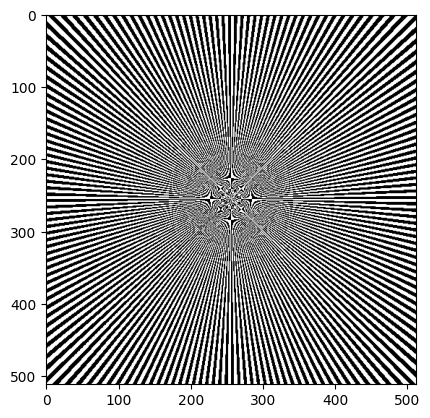

In [46]:
def generateimg(N, degrees):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    xv, yv = np.meshgrid(x, y)

    angulos_img = np.arctan2(-yv, xv)
    angulos_img = np.degrees(angulos_img) % 360

    imagem = ((angulos_img // degrees) % 2) * 255

    return imagem.astype(np.uint8)

imagem = generateimg(512, 1)
plt.imshow(imagem, cmap='gray')
plt.show()

(array([ 33256.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 221444.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

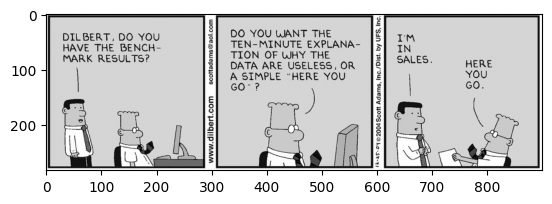

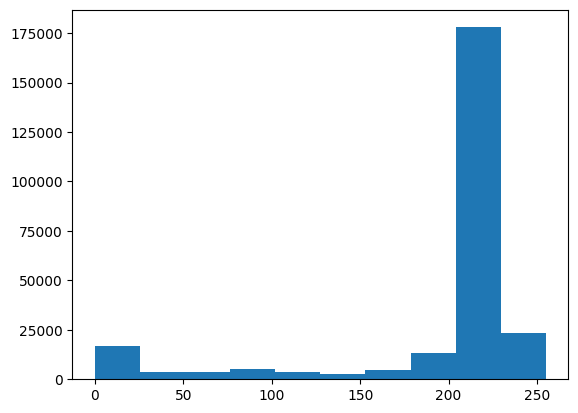

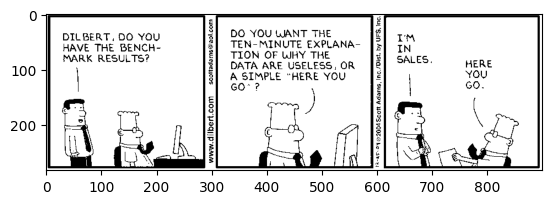

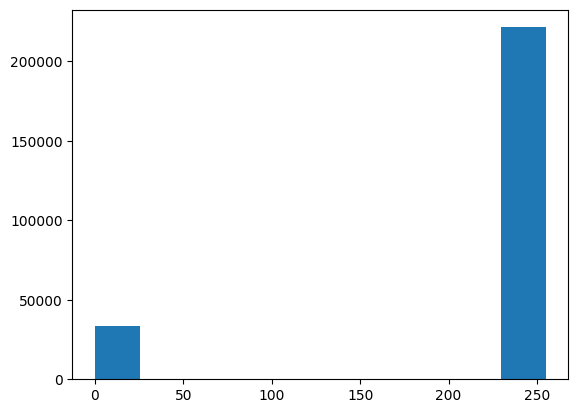

In [81]:
img_xpto = cv2.imread("xpto3.jpeg", 0)

plt.imshow(img_xpto, cmap='gray')

plt.figure()
plt.hist(img_xpto.ravel())

transform_img_xpto = img_xpto.ravel()

new_imgxpto = []

for i in range(len(transform_img_xpto)):
    if transform_img_xpto[i] >= 128:
        new_imgxpto.append(255)
    else:
        new_imgxpto.append(0)       

y_img = np.array(new_imgxpto).reshape(img_xpto.shape)

plt.figure()

plt.imshow(y_img, cmap='gray')

plt.figure()

plt.hist(y_img.ravel())